# Glassdoor Reviews Data Cleaning
Dataset: `data/raw/glass_reviews.csv`

### Initial Cleaning Stages:
- **Part 1:** Fix corrupted index header (`review_id`)
- **Part 2:** Drop 100% unpopulated / null columns (`review_advice`, `career_opportunities_rating`)

In [7]:
import os
import pandas as pd

# Load raw dataset with fallback for working directory
file_path = 'data/raw/glass_reviews.csv'
if not os.path.exists(file_path):
    file_path = '../../data/raw/glass_reviews.csv'

df = pd.read_csv(file_path)

# 1. Print original columns before making any changes
print("=== Original Columns Count:", len(df.columns), "===")
print("Original Columns List:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\n=== Checking Missing Values in Target Unpopulated Columns ===")
print(df[['review_advice', 'career_opportunities_rating']].isnull().sum())
df.head(10)

=== Original Columns Count: 28 ===
Original Columns List:
0: Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:
1: rating_date
2: count_helpful
3: count_unhelpful
4: employee_length
5: employee_status
6: employee_type
7: flag_covid
8: flag_featured
9: flags_business_outlook
10: flags_ceo_approval
11: flags_recommend_frend
12: rating_culture_values
13: rating_diversity_inclusion
14: rating_overall
15: rating_work_life
16: summary
17: company_name
18: review_advice
19: career_opportunities_rating
20: employee_location
21: employee_job_title
22: advice_to_management
23: review_pros
24: review_cons
25: rating_compensation_benefits
26: rating_senior_leadership
27: rating_career_opportunities

=== Checking Missing Values in Target Unpopulated Columns ===
review_advice                  127
career_opportunities_rating    127
dtype: int64


,Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:,rating_date,count_helpful,count_unhelpful,employee_length,employee_status,employee_type,flag_covid,flag_featured,flags_business_outlook,...,review_advice,career_opportunities_rating,employee_location,employee_job_title,advice_to_management,review_pros,review_cons,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities
0,1,2025-06-03T00:00:00.000Z,0,0,0,REGULAR,Current employee,False,False,NaN,...,NaN,NaN,"Richmond, VA",Warehouse Fulfillment Associate,don’t micro manage,not interactive \ncan leave or take off whenev...,inhumane \ndraining physically &amp; mentally,0,0,0
1,2,2025-05-29T00:00:00.000Z,0,0,1,CONTRACT,"Current employee, less than 1 year",False,False,POSITIVE,...,NaN,NaN,"Brampton, ON",Warehouse Associate,Remove all attitude manager from warehouse,good and easy work enviorment,"Sticks rules and completing targets any how, o...",5,3,5
2,3,2025-05-28T00:00:00.000Z,0,0,1,REGULAR,"Current employee, less than 1 year",False,False,POSITIVE,...,NaN,NaN,"Bolton, ON",Warehouse Associate,NaN,"help to grow , good pay ,","limited opportunities for advancement,No clear...",5,5,5
3,4,2025-05-26T00:00:00.000Z,0,0,2,PART_TIME,Current employees,False,False,POSITIVE,...,NaN,NaN,"Swedesboro, NJ",Employee,NaN,Plenty of work\nMeet new people,Tough on the body\nLabor intensive,2,2,3
4,5,2025-05-23T00:00:00.000Z,0,0,0,REGULAR,Current employee,False,False,NaN,...,NaN,NaN,"Whitby, ON",Fulfillment Associate,NaN,Good Holiday pay \nAdditional benefits for per...,Not hiring permanent employees directly,0,0,0
5,6,2025-05-18T00:00:00.000Z,0,0,2,REGULAR,Former employees,False,False,NaN,...,NaN,NaN,"Kenosha, WI",Warehouse Associate,NaN,"Nice people, Great pay and benefits.",management does not care about its employees. ...,4,2,3
6,7,2025-05-17T00:00:00.000Z,0,0,4,REGULAR,Current employees,False,False,NEGATIVE,...,NaN,NaN,"Oklahoma City, OK",Associate,should have physical strength,"learn lift trucks, pallet jack, flex schedule/...","fast paced working environment, weight lifting",5,5,4
7,8,2025-05-15T00:00:00.000Z,0,0,0,REGULAR,Current employee,False,False,NaN,...,NaN,NaN,NaN,NaN,no,decent work that wasnt too miserable,people in charge wasnt very good,3,2,4
8,9,2025-05-14T00:00:00.000Z,0,0,1,REGULAR,"Former employee, less than 1 year",False,False,NaN,...,NaN,NaN,"Clarksville, TN",Fulfillment Associate,Get better,"Good pay, not too long hours",Management absolutely is terrible at communica...,4,0,3
9,10,2025-05-14T00:00:00.000Z,0,0,1,NaN,"Former employee, less than 1 year",False,False,NaN,...,NaN,NaN,"Appleton, WI",Warehouse Worker,NaN,Workout and regularly routine habit,"More work life, less sleep .",0,0,0


In [8]:
# Part 1: Rename the corrupted first column header to 'review_id'
corrupted_header = df.columns[0]
print(f"Renaming corrupted header: '{corrupted_header}' -> 'review_id'")
df.rename(columns={corrupted_header: 'review_id'}, inplace=True)

# Part 2: Drop 100% unpopulated / null columns
cols_to_drop = ['review_advice', 'career_opportunities_rating']
print(f"Dropping unpopulated columns: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

# Print updated columns list
print("\n=== Updated Columns Count:", len(df.columns), "===")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Renaming corrupted header: 'Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:' -> 'review_id'
Dropping unpopulated columns: ['review_advice', 'career_opportunities_rating']

=== Updated Columns Count: 26 ===
0: review_id
1: rating_date
2: count_helpful
3: count_unhelpful
4: employee_length
5: employee_status
6: employee_type
7: flag_covid
8: flag_featured
9: flags_business_outlook
10: flags_ceo_approval
11: flags_recommend_frend
12: rating_culture_values
13: rating_diversity_inclusion
14: rating_overall
15: rating_work_life
16: summary
17: company_name
18: employee_location
19: employee_job_title
20: advice_to_management
21: review_pros
22: review_cons
23: rating_compensation_benefits
24: rating_senior_leadership
25: rating_career_opportunities


In [9]:
# Display dataframe
df.head()


df.columns

Index(['review_id', 'rating_date', 'count_helpful', 'count_unhelpful',
       'employee_length', 'employee_status', 'employee_type', 'flag_covid',
       'flag_featured', 'flags_business_outlook', 'flags_ceo_approval',
       'flags_recommend_frend', 'rating_culture_values',
       'rating_diversity_inclusion', 'rating_overall', 'rating_work_life',
       'summary', 'company_name', 'employee_location', 'employee_job_title',
       'advice_to_management', 'review_pros', 'review_cons',
       'rating_compensation_benefits', 'rating_senior_leadership',
       'rating_career_opportunities'],
      dtype='object')

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

def plot_rating_bar_chart(data, column, title=None, color='#2b5c8f', exclude_zero=False, ax=None):
    """
    Reusable function to plot a bar chart of rating distributions.
    
    Parameters:
    - data: pd.DataFrame containing the reviews
    - column: str, name of the rating column
    - title: str, optional custom title
    - color: str, bar fill color
    - exclude_zero: bool, whether to exclude 0 (Glassdoor 0 represents unrated)
    - ax: matplotlib.axes.Axes, optional axis for plotting within subplots
    """
    subset = data[column].dropna()
    if exclude_zero:
        subset = subset[subset > 0]
        x_label = "Star Rating (1 to 5)"
    else:
        x_label = "Rating Value (0 = Unrated, 1-5 Stars)"
        
    # Compute frequency of each rating value
    counts = subset.value_counts().sort_index()
    
    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        show_plot = True
        
    # Plot bar chart
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=color,
        edgecolor='black',
        alpha=0.85,
        width=0.55
    )
    
    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    clean_title = title if title else f"Distribution of {column.replace('_', ' ').title()}"
    ax.set_title(clean_title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(x_label, fontsize=11, labelpad=8)
    ax.set_ylabel("Number of Reviews", fontsize=11, labelpad=8)
    max_val = max(counts.values) if len(counts) > 0 else 10
    ax.set_ylim(0, max_val * 1.18)
    
    if show_plot:
        plt.tight_layout()
        plt.show()


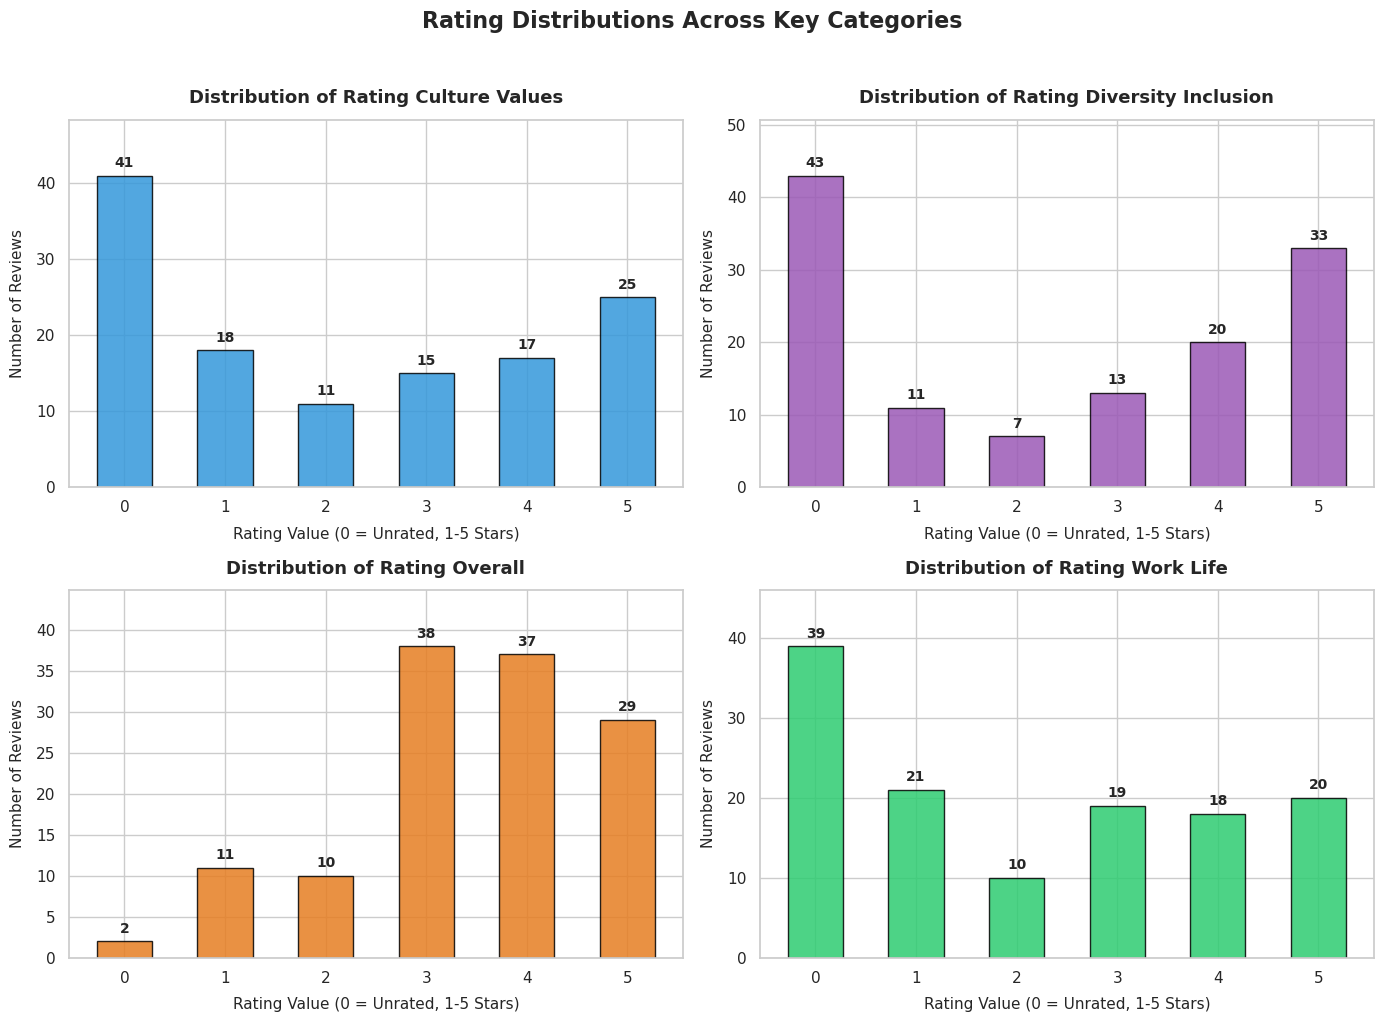

In [11]:
target_rating_cols = [
    'rating_culture_values',
    'rating_diversity_inclusion',
    'rating_overall',
    'rating_work_life'
]

# Call the reusable function to display all 4 columns side-by-side in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

for i, col in enumerate(target_rating_cols):
    plot_rating_bar_chart(df, col, color=colors[i], exclude_zero=False, ax=axes[i])

plt.suptitle("Rating Distributions Across Key Categories", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== Review Counts by Extracted Year ===
rating_year
2024.0    29
2025.0    96
NaN        2
Name: count, dtype: int64


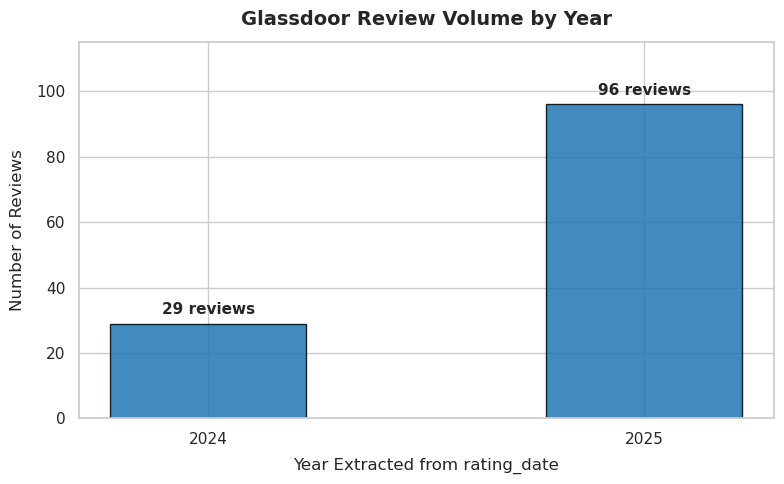

In [12]:
# Convert rating_date to datetime and extract year
df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', utc=True)
df['rating_year'] = df['rating_date'].dt.year

print("=== Review Counts by Extracted Year ===")
year_counts = df['rating_year'].value_counts(dropna=False).sort_index()
print(year_counts)

# Plot Bar Chart for Review Volume by Year
fig, ax = plt.subplots(figsize=(8, 5))
valid_year_counts = df['rating_year'].dropna().astype(int).value_counts().sort_index()

bars = ax.bar(
    valid_year_counts.index.astype(str),
    valid_year_counts.values,
    color='#1f77b4',
    edgecolor='black',
    alpha=0.85,
    width=0.45
)

# Annotate bar tops with exact count
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height} reviews',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title("Glassdoor Review Volume by Year", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year Extracted from rating_date", fontsize=12, labelpad=8)
ax.set_ylabel("Number of Reviews", fontsize=12, labelpad=8)
ax.set_ylim(0, max(valid_year_counts.values) * 1.2)
plt.tight_layout()
plt.show()


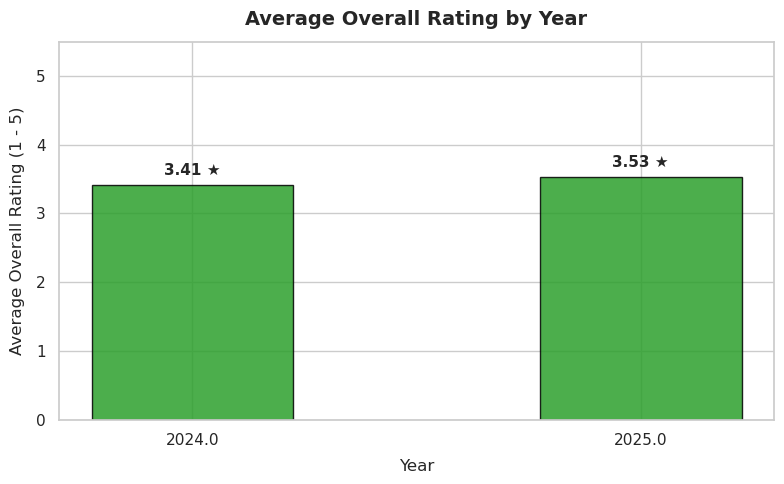

In [13]:
avg_by_year = df.groupby(df['rating_year'].dropna().astype(int))['rating_overall'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    avg_by_year.index.astype(str),
    avg_by_year.values,
    color='#2ca02c',
    edgecolor='black',
    alpha=0.85,
    width=0.45
)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f} ★',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title("Average Overall Rating by Year", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year", fontsize=12, labelpad=8)
ax.set_ylabel("Average Overall Rating (1 - 5)", fontsize=12, labelpad=8)
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()


## Create column that validate if the flag covid and flag features are all false, return to the row that has flag covid and flag features are true 